In [ ]:
#Importing the required libraries for this analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Loading each sheet into its own variable
users=pd.read_excel('/duolingo_dataset.xlsx',sheet_name='users')
sessions=pd.read_excel('/duolingo_dataset.xlsx',sheet_name='sessions')
notifications=pd.read_excel('/duolingo_dataset.xlsx',sheet_name='notifications')
churn_labels=pd.read_excel('/duolingo_dataset.xlsx',sheet_name='churn_labels')

#Having a peak at each sheet in the workbook
print("USERS:")
print(users.head(5))

print("\nSESSIONS:")
print(sessions.head(5))

print("\nNOTIFICATIONS:")
print(notifications.head(5))

print("\nCHURN LABELS:")
print(churn_labels.head(5))


USERS:
    USER ID SIGNUP DATE COUNTRY DEVICE TYPE LANGUAGE LEARNED AGE GROUP  \
0  USR00001  2024-04-01      UK     Android          Spanish     25-34   
1  USR00002  2024-01-07      KR     Android         Japanese     25-34   
2  USR00003  2024-02-04      FR         iOS       Portuguese     13-17   
3  USR00004  2024-02-24      MX     Android         Mandarin     18-24   
4  USR00005  2024-04-01      US     Android       Portuguese     18-24   

  LEAGUE TIER  IS PAID  
0      Bronze     True  
1      Silver    False  
2     Emerald    False  
3        Gold    False  
4    Sapphire    False  

SESSIONS:
  SESSION ID   USER ID SESSION DATE  DURATION SECONDS  LESSONS COMPLETED  \
0  SES000001  USR00001   2024-04-02               690                  4   
1  SES000002  USR00001   2024-04-03               460                  2   
2  SES000003  USR00002   2024-01-07               472                  2   
3  SES000004  USR00002   2024-01-08               345                  3   
4  SES0

In [ ]:
#Viewing the names of each column in sheet
print("users columns:",list(users.columns))
print("sessions columns:",list(sessions.columns))
print("notifications columns:",list(notifications.columns))
print("churn_labels columns:",list(churn_labels.columns))


users columns: ['USER ID', 'SIGNUP DATE', 'COUNTRY', 'DEVICE TYPE', 'LANGUAGE LEARNED', 'AGE GROUP', 'LEAGUE TIER', 'IS PAID']
sessions columns: ['SESSION ID', 'USER ID', 'SESSION DATE', 'DURATION SECONDS', 'LESSONS COMPLETED', 'XP EARNED', 'STREAK DAY', 'UNIT NUMBER', 'LESSON NUMBER']
notifications columns: ['NOTIFICATION ID', 'USER ID', 'SENT AT', 'TYPE', 'OPENED', 'RESULTED IN SESSION']
churn_labels columns: ['USER ID', 'LAST ACTIVE DATE', 'CHURNED 30D', 'DAYS INACTIVE', 'RISK SEGMENT']


In [ ]:
#Since "USER ID" is identified in each sheet of this workbook,we can now merge them using itas a connector
master=churn_labels.copy()
print("start:", master.shape)

#step 1: add user profile info from the users table
master=master.merge(users,on='USER ID',how='left')
print("After adding users:",master.shape)

#step 2-summarise sessions per user,based on their average streak,etc
session_summary=sessions.groupby('USER ID').agg(
    total_sessions=('SESSION ID', 'count'),#How many sessions total
    avg_duration=('DURATION SECONDS','mean'),#average session length
    avg_lessons=('LESSONS COMPLETED','mean'),#average lessons completed
    total_xp=('XP EARNED','sum'),#total xp earned
    avg_streak=('STREAK DAY','mean'),#average streak
    max_streak=('STREAK DAY','max'),#average streak
).reset_index()
master=master.merge(session_summary,on='USER ID',how='left')
print("After adding session summary:",master.shape)

#step 3-summarise notifications per user
notification_summary=notifications.groupby('USER ID').agg(
    total_notifications=('NOTIFICATION ID', 'count'),
    opened_notifications=('OPENED','sum'),
    sessions_from_notifications=('RESULTED IN SESSION','sum')
).reset_index()
master=master.merge(notification_summary,on='USER ID',how='left')
print("After adding notification summary:",master.shape)

start: (500, 5)
After adding users: (500, 12)
After adding session summary: (500, 18)
After adding notification summary: (500, 21)


In [ ]:
!pip install itables #turns your dataframe into a clean interactive table

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 60.7 MB/s eta 0:00:00


In [ ]:
from itables import show
from google.colab import data_table
data_table.enable_dataframe_formatter()
master

,USER ID,LAST ACTIVE DATE,CHURNED 30D,DAYS INACTIVE,RISK SEGMENT,SIGNUP DATE,COUNTRY,DEVICE TYPE,LANGUAGE LEARNED,AGE GROUP,...,IS PAID,total_sessions,avg_duration,avg_lessons,total_xp,avg_streak,max_streak,total_notifications,opened_notifications,sessions_from_notifications
0,USR00001,2024-04-03,False,27,Low,2024-04-01,UK,Android,Spanish,25-34,...,True,2,575.000000,3.000000,154,1.500000,2,4,2,0
1,USR00002,2024-05-26,False,0,Low,2024-01-07,KR,Android,Japanese,25-34,...,False,21,535.523810,2.952381,1237,4.476190,9,4,1,0
2,USR00003,2024-02-07,True,83,Medium,2024-02-04,FR,iOS,Portuguese,13-17,...,False,4,594.000000,3.500000,305,2.500000,4,7,3,2
3,USR00004,2024-03-09,True,52,High,2024-02-24,MX,Android,Mandarin,18-24,...,False,3,332.000000,3.000000,149,1.333333,2,14,6,2
4,USR00005,2025-04-01,False,0,High,2024-04-01,US,Android,Portuguese,18-24,...,False,28,496.892857,2.750000,1594,9.357143,16,8,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,USR00496,2024-02-21,True,69,High,2024-02-20,UK,iOS,German,25-34,...,False,2,527.000000,1.500000,71,0.500000,1,6,3,0
496,USR00497,2024-01-05,True,116,Low,2024-01-04,MX,Web,German,45+,...,False,1,712.000000,3.000000,84,0.000000,0,18,7,1
497,USR00498,2024-03-18,True,43,Low,2024-02-24,US,iOS,French,13-17,...,False,13,460.692308,3.000000,834,4.846154,9,15,5,1
498,USR00499,2024-05-20,False,0,Low,2024-03-11,AU,Web,French,13-17,...,False,7,561.857143,3.285714,450,3.428571,5,18,10,5


In [ ]:

#pd.set_option('display.max_rows',None)This removes the row limit so all row displays
#pd.set_option('display.max_columns',None)This removes the column limit so all column displays
#print(master)

#to reset it:
#pd.reset_option('display.max_rows')
#pd.reset_option('display.max_rows')

In [ ]:
print(master.isnull().sum())

USER ID                        0
LAST ACTIVE DATE               0
CHURNED 30D                    0
DAYS INACTIVE                  0
RISK SEGMENT                   0
SIGNUP DATE                    0
COUNTRY                        0
DEVICE TYPE                    0
LANGUAGE LEARNED               0
AGE GROUP                      0
LEAGUE TIER                    0
IS PAID                        0
total_sessions                 0
avg_duration                   0
avg_lessons                    0
total_xp                       0
avg_streak                     0
max_streak                     0
total_notifications            0
opened_notifications           0
sessions_from_notifications    0
dtype: int64


In [ ]:
#Check for duplicate rows
print('Duplicate rows:',master.duplicated().sum())

Duplicate rows: 0


In [ ]:
#check data types
print(master.dtypes)

USER ID                         object
LAST ACTIVE DATE                object
CHURNED 30D                       bool
DAYS INACTIVE                    int64
RISK SEGMENT                    object
SIGNUP DATE                     object
COUNTRY                         object
DEVICE TYPE                     object
LANGUAGE LEARNED                object
AGE GROUP                       object
LEAGUE TIER                     object
IS PAID                           bool
total_sessions                   int64
avg_duration                   float64
avg_lessons                    float64
total_xp                         int64
avg_streak                     float64
max_streak                       int64
total_notifications              int64
opened_notifications             int64
sessions_from_notifications      int64
dtype: object


In [ ]:
#converting some datatypes

#Fix dates
master['SIGNUP DATE']=pd.to_datetime(master['SIGNUP DATE'])
master['LAST ACTIVE DATE']=pd.to_datetime(master['LAST ACTIVE DATE'])

#Fix total sessions
master['total_sessions']=master['total_sessions'].astype(int)

#others
master['CHURNED 30D']=master['CHURNED 30D'].astype(int)
master['IS PAID']=master['IS PAID'].astype(int)

print(master.dtypes)


USER ID                                object
LAST ACTIVE DATE               datetime64[ns]
CHURNED 30D                             int64
DAYS INACTIVE                           int64
RISK SEGMENT                           object
SIGNUP DATE                    datetime64[ns]
COUNTRY                                object
DEVICE TYPE                            object
LANGUAGE LEARNED                       object
AGE GROUP                              object
LEAGUE TIER                            object
IS PAID                                 int64
total_sessions                          int64
avg_duration                          float64
avg_lessons                           float64
total_xp                                int64
avg_streak                            float64
max_streak                              int64
total_notifications                     int64
opened_notifications                    int64
sessions_from_notifications             int64
dtype: object


**EXPLORATORY DATA ANALYSIS(EDA)**

CHURNED 30D
1    268
0    232
Name: count, dtype: int64


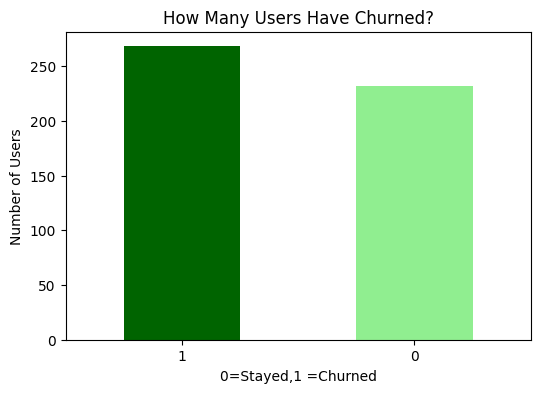

In [ ]:
#Churn status
churn_status=master['CHURNED 30D'].value_counts()
print(churn_status)

#Visualize
churn_status.plot(kind='bar',color=['darkgreen','lightgreen'],figsize=(6,4))
plt.title('How Many Users Have Churned?')
plt.ylabel('Number of Users')
plt.xlabel('0=Stayed,1 =Churned')
plt.xticks(rotation=0)
plt.show()

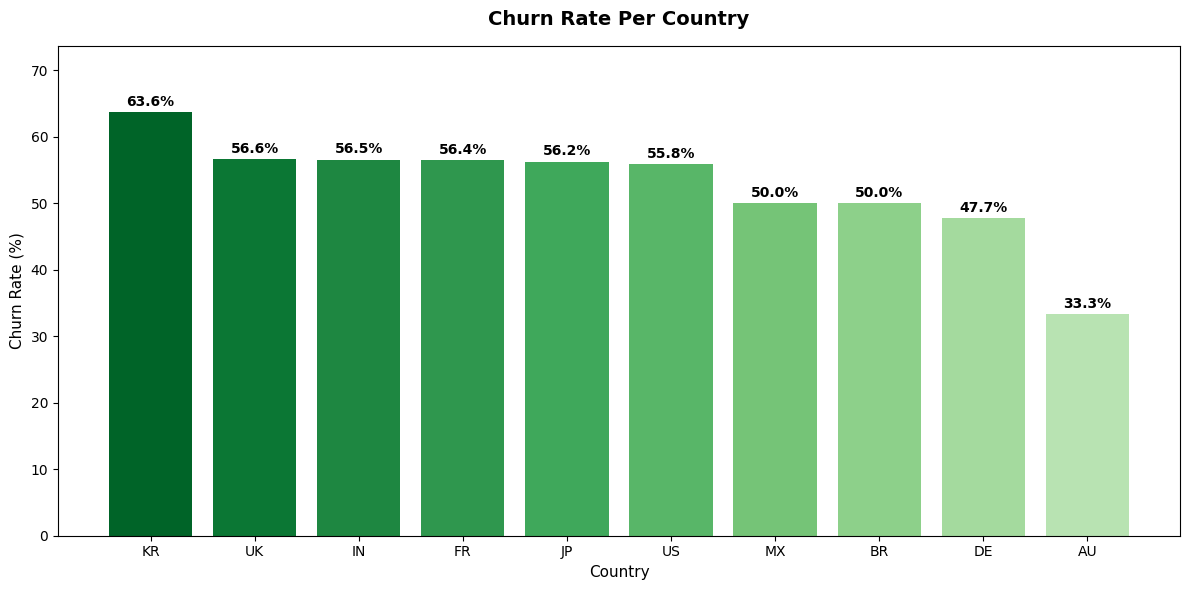

In [ ]:
import numpy as np

#Calculate the churn rate per country
churn_rate_country=master.groupby('COUNTRY')['CHURNED 30D'].mean().sort_values(ascending=False)
churn_rate_country=churn_rate_country*100

#create gradient colors
colors=plt.cm.Greens(np.linspace(0.9,0.3,len(churn_rate_country)))

#plot
fig,ax=plt.subplots(figsize=(12,6))
bars=ax.bar(churn_rate_country.index,churn_rate_country.values,color=colors)

#add the data labels on top of each bar for visual appeal
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.5,
      f'{height:.1f}%',
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold'
  )

ax.set_title('Churn Rate Per Country',fontsize=14,fontweight='bold',pad=15)
ax.set_xlabel('Country',fontsize=11)
ax.set_ylabel('Churn Rate (%)',fontsize=11)
ax.set_ylim(0,max(churn_rate_country.values)+10)#Extra Space for labels
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Do IOS,Andriod,or Web Users Churn More?**

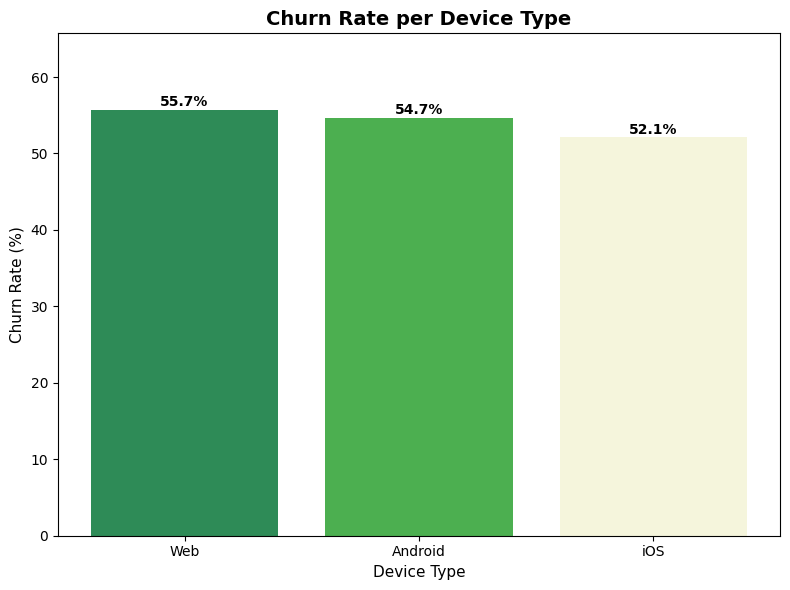

In [ ]:
churn_by_device=master.groupby('DEVICE TYPE')['CHURNED 30D'].mean().sort_values(ascending=False)*100

#create gradient colors
colors=plt.cm.Greens(np.linspace(0.9,0.3,len(churn_rate_country)))

#plot
fig,ax=plt.subplots(figsize=(8,6))
bars=ax.bar(churn_by_device.index,churn_by_device.values,color=['#2E8B57','#4CAF50','#F5F5DC'])

#add the data labels on top of each bar for visual appeal
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.5,
      f'{height:.1f}%',
      ha='center',
      #va='bottom',
      fontsize=10,
      fontweight='bold'
  )

ax.set_title('Churn Rate per Device Type',fontsize=14,fontweight='bold')
ax.set_xlabel('Device Type',fontsize=11)
ax.set_ylabel('Churn Rate (%)',fontsize=11)
ax.set_ylim(0,max(churn_by_device.values)+10)#Extra Space for labels
#plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**What Age Bracket Leaves The Most?**

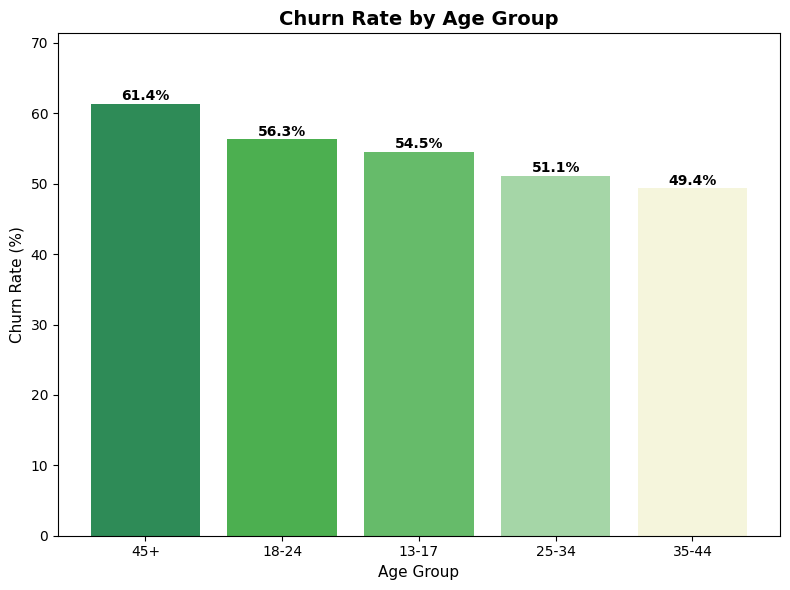

In [ ]:
churn_by_age=master.groupby('AGE GROUP')['CHURNED 30D'].mean().sort_values(ascending=False)*100

#plot
fig,ax=plt.subplots(figsize=(8,6))
bars=ax.bar(churn_by_age.index,churn_by_age.values,color=['#2E8B57','#4CAF50','#66BB6A','#A5D6A7','#F5F5DC'])

#add the data labels on top of each bar for visual appeal
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.5,
      f'{height:.1f}%',
      ha='center',
      #va='bottom',
      fontsize=10,
      fontweight='bold'
  )

ax.set_title('Churn Rate by Age Group',fontsize=14,fontweight='bold')
ax.set_xlabel('Age Group',fontsize=11)
ax.set_ylabel('Churn Rate (%)',fontsize=11)
ax.set_ylim(0,max(churn_by_age.values)+10)#Extra Space for labels
#plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Churn by Language**

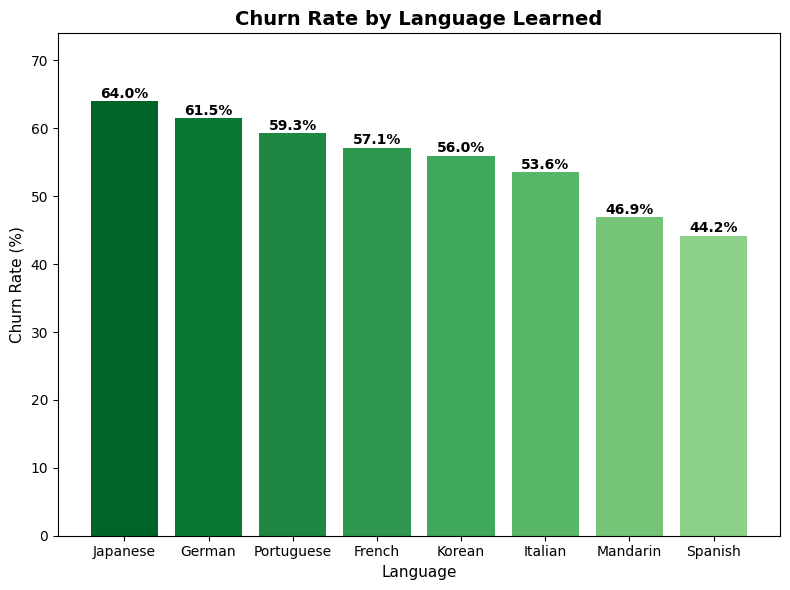

In [ ]:
churn_by_language_learned =master.groupby('LANGUAGE LEARNED')['CHURNED 30D'].mean().sort_values(ascending=False)*100

#plot
fig,ax=plt.subplots(figsize=(8,6))
bars=ax.bar(churn_by_language_learned.index,churn_by_language_learned.values,color=colors)

#add the data labels on top of each bar for visual appeal
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.5,
      f'{height:.1f}%',
      ha='center',
      #va='bottom',
      fontsize=10,
      fontweight='bold'
  )

ax.set_title('Churn Rate by Language Learned',fontsize=14,fontweight='bold')
ax.set_xlabel('Language',fontsize=11)
ax.set_ylabel('Churn Rate (%)',fontsize=11)
ax.set_ylim(0,max(churn_by_language_learned.values)+10)#Extra Space for labels
#plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Churn by League**

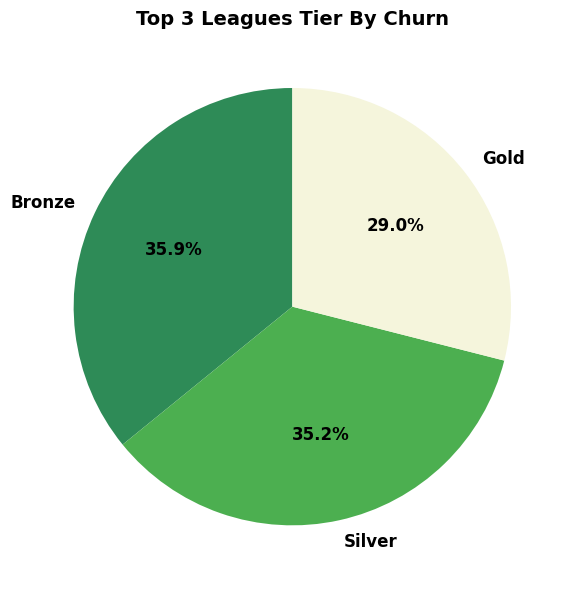

In [ ]:
churn_by_league=master.groupby('LEAGUE TIER')['CHURNED 30D'].sum().sort_values(ascending=False)
top_3=churn_by_league.head(3)
top_3

fig,ax=plt.subplots(figsize=(8,6))
ax.pie(top_3.values,
       labels=top_3.index,
       colors=['#2E8B57','#4CAF50','#F5F5DC'],
       autopct='%1.1f%%',
       startangle=90,
       textprops={'fontsize':12,'fontweight':'bold'})

ax.set_title('Top 3 Leagues Tier By Churn',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

**Churn caused by streak Duration**




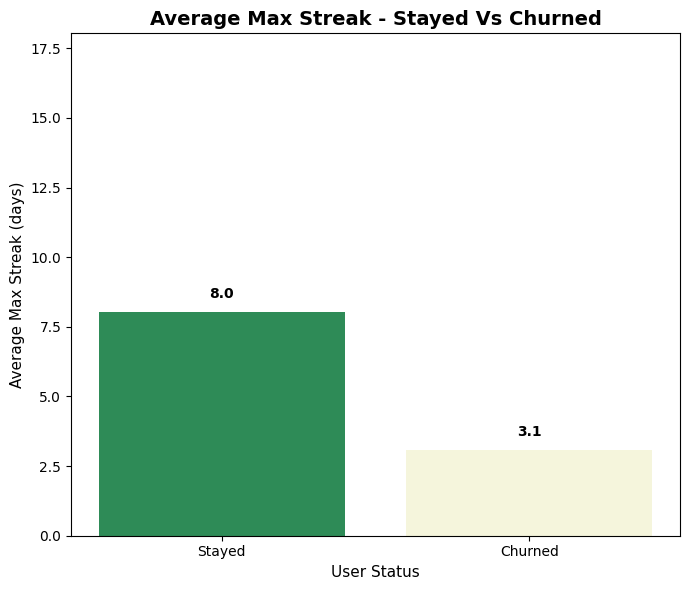

In [ ]:
streak_duration_churn=master.groupby('CHURNED 30D')['max_streak'].mean()

#plot
fig,ax=plt.subplots(figsize=(7,6))
bars=ax.bar(['Stayed','Churned'],streak_duration_churn.values,color=['#2E8B57','#F5F5DC'])

#add the data labels on top of each bar for visual appeal
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.5,
      f'{height:.1f}',
      ha='center',
      #va='bottom',
      fontsize=10,
      fontweight='bold'
  )

ax.set_title('Average Max Streak - Stayed Vs Churned',fontsize=14,fontweight='bold')
ax.set_xlabel('User Status',fontsize=11)
ax.set_ylabel('Average Max Streak (days)',fontsize=11)
ax.set_ylim(0,max(streak_duration_churn.values)+10)#Extra Space for labels
#plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

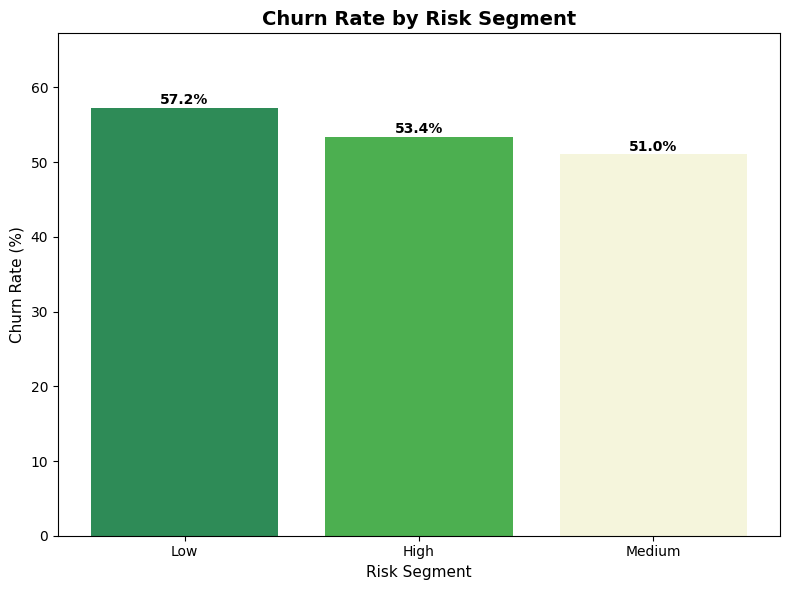

In [ ]:
churn_by_risk_segment = master.groupby('RISK SEGMENT')['CHURNED 30D'].mean().sort_values(ascending=False) * 100

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(churn_by_risk_segment.index, churn_by_risk_segment.values, color=['#2E8B57', '#4CAF50', '#F5F5DC'])

# Add data labels on top of each bar
for bar in bars:
  height = bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      height + 0.5,
      f'{height:.1f}%',
      ha='center',
      fontsize=10,
      fontweight='bold'
  )

ax.set_title('Churn Rate by Risk Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Segment', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, max(churn_by_risk_segment.values) + 10) # Extra space for labels
plt.tight_layout()
plt.show()

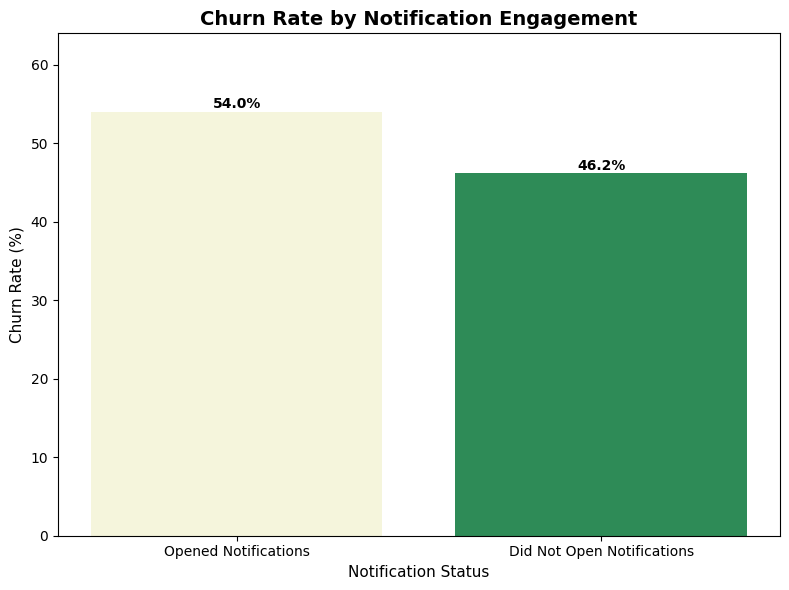

In [ ]:
# Create a new column to categorize users based on whether they opened any notifications
master['opened_any_notification'] = master['opened_notifications'].apply(lambda x: 1 if x > 0 else 0)

# Calculate the churn rate for users who opened notifications vs. those who did not
churn_by_notification_opened = master.groupby('opened_any_notification')['CHURNED 30D'].mean().sort_values(ascending=False) * 100

# Map the 0/1 to descriptive labels for plotting
churn_by_notification_opened.index = churn_by_notification_opened.index.map({0: 'Did Not Open Notifications', 1: 'Opened Notifications'})

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(churn_by_notification_opened.index, churn_by_notification_opened.values, color=['#F5F5DC', '#2E8B57'])

# Add data labels on top of each bar
for bar in bars:
  height = bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      height + 0.5,
      f'{height:.1f}%',
      ha='center',
      fontsize=10,
      fontweight='bold'
  )

ax.set_title('Churn Rate by Notification Engagement', fontsize=14, fontweight='bold')
ax.set_xlabel('Notification Status', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, max(churn_by_notification_opened.values) + 10) # Extra space for labels
plt.tight_layout()
plt.show()

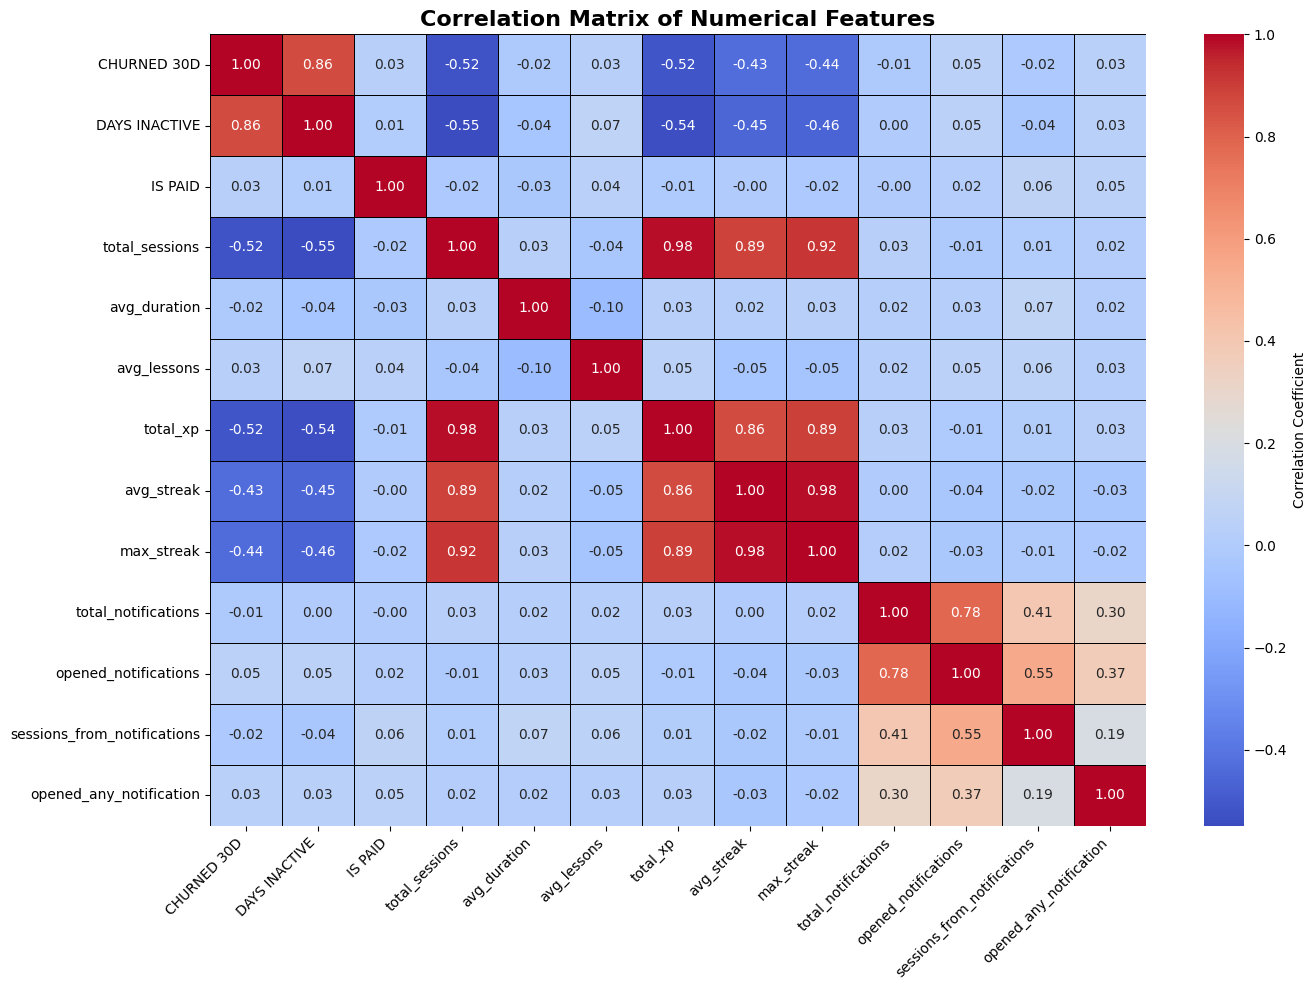

In [ ]:
# Select only numerical columns for correlation matrix
numerical_cols = master.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = master[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**PART B: DEPLOYING A MACHINE LEARNING ALGORITHM**

**step 1: Identifying features and Target sets**

In [ ]:
#These are the columns the model learns from(i.e features)
features=['total_sessions','avg_duration','avg_lessons','total_xp','avg_streak','max_streak','opened_notifications','sessions_from_notifications',
          'COUNTRY','AGE GROUP','LEAGUE TIER','IS PAID','DEVICE TYPE','LANGUAGE LEARNED','opened_any_notification']

#What we are predicting,Churned or not
X=master[features]#input(features)
Y=master['CHURNED 30D']#output(target)

print('Input shape:', X.shape)
print('Target shape:', Y.shape)

Input shape: (500, 15)
Target shape: (500,)


**Step 2: Split the Data into Train and Test sets**


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,
    test_size=0.2,#20% goes to testing
    stratify=Y,#keeps the churned/stayed ratio balanced in both splits
    random_state=42#ensures we get the same split everytime it is runned
)

print("Training size:",X_train.shape)
print("Testing size:",X_test.shape)

#That is, 400 users to train on and 100 users to test on

Training size: (400, 15)
Testing size: (100, 15)


**Step 3:Training the Actual Model**

In [ ]:
#XGBoost will be used to train the actual model. Think of it as a very smart student that learns from mistakes over and over until it gets really good at predicting churn
from xgboost import XGBClassifier
import pandas as pd # Import pandas for one-hot encoding

# #the XGBClassifier only supports floats,int,etc and not object or string types,thus,
#Identify categorical columns for one-hot encoding
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply one-hot encoding to training and testing data
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure all columns are aligned between train and test sets after encoding
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

#now,we can build the model
model=XGBClassifier(
    n_estimators=200,#How many times it learns and correct itself
    max_depth=4,#depth of learning round
    learning_rate=0.05,#how fast it learns(that is,the slower the better and more careful)
    random_state=42#same result ecverytime we run it
)

#Train the model using the encoded data
model.fit(X_train_encoded,Y_train)
print("---------Model Training Complete!----------")

---------Model Training Complete!----------


In [ ]:
from sklearn.metrics import classification_report,roc_auc_score

#let the model make predictions on the test set
y_pred=model.predict(X_test_encoded)

# Evaluate the model
print("Classification Report:")
print(classification_report(Y_test, y_pred))

print("\nROC AUC Score:")
print(roc_auc_score(Y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.74      0.73        46
           1       0.77      0.76      0.77        54

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.75      0.75      0.75       100


ROC AUC Score:
0.749194847020934


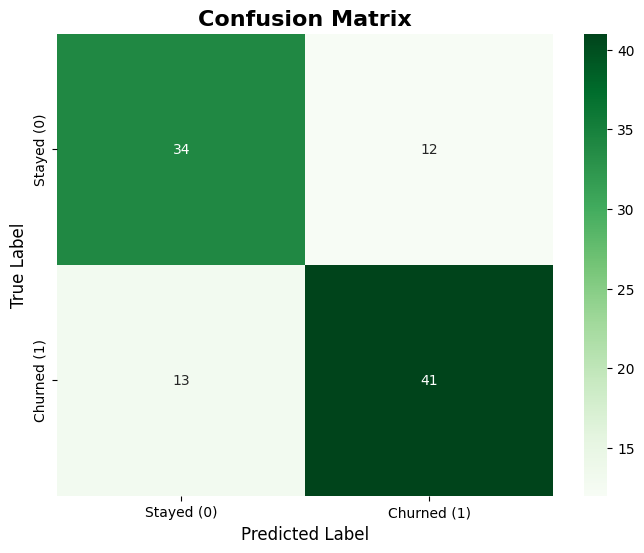

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(Y_test, y_pred)

# Define labels for the confusion matrix
labels = ['Stayed (0)', 'Churned (1)']

# Plot the confusion matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

/tmp/ipykernel_364/1183760387.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', ax=ax)


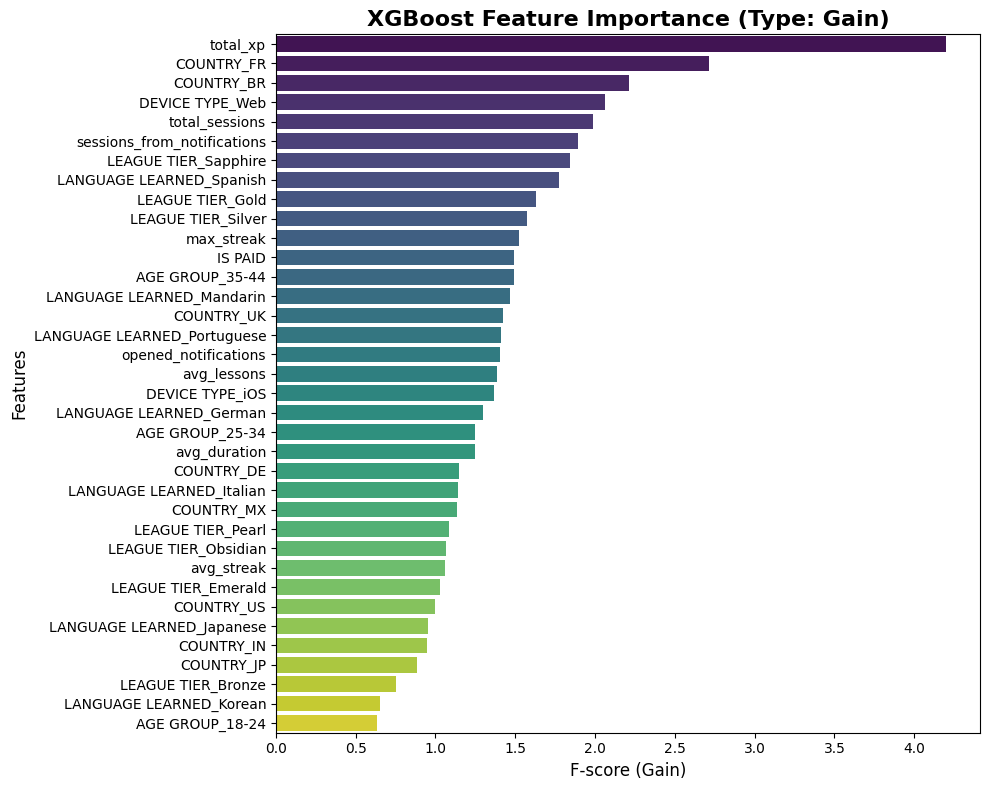

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Get feature importances from the trained model
feature_importances = model.get_booster().get_score(importance_type='gain')

# Convert to a DataFrame for easier sorting and plotting
importance_df = pd.DataFrame({
    'Feature': list(feature_importances.keys()),
    'Importance': list(feature_importances.values())
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', ax=ax)
ax.set_title('XGBoost Feature Importance (Type: Gain)', fontsize=16, fontweight='bold')
ax.set_xlabel('F-score (Gain)', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

**Step 4: Test the model accurarcy**